# House Price Prediction

### PROBLEM STATEMENT

Accurately predicting house prices is a critical task for buyers, sellers, and real
estate professionals. This project uses the Ames Housing dataset to build a
regression model that predicts a house's sale price based on its physical
characteristics, quality ratings, and location.

The goal is to compare multiple regression models, engineer meaningful features
from the raw data, and tune the best-performing model to produce accurate,
interpretable price predictions.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error

import joblib

## 1. Load the Data

In [2]:
home = pd.read_csv('train.csv')
home.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
home.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

The code above shows the basic information about the data set like number of columns, data type of columns and nuber of rows. The data set contains 3 float columns, 35 integer columns and 43 string scumns giving a total of 81 columns.

In [4]:
home.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


The code above shows the statistical information about the data set 

In [5]:
home.dtypes


Id                 int64
MSSubClass         int64
MSZoning             str
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType             str
SaleCondition        str
SalePrice          int64
Length: 81, dtype: object

In [6]:
home.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

## 2. Data Cleaning

Handling missing values by displaying columns with missing values, along side the amount of missing values they have and filling them with the median of the entire row, none in case of missing categorical values, mode of the entire columns and 0s where necessary

Displaying missing values for columns containing missing values

In [7]:
missing = home.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0])

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


Filling missing values with the median of the entire column, none in case of missing categorical values, mode of the entire columns and 0s where necessary

In [8]:
none_fill_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
                   'GarageQual', 'GarageFinish', 'GarageType', 'GarageCond',
                   'BsmtFinType2', 'BsmtExposure', 'BsmtCond', 'BsmtQual', 'BsmtFinType1',
                   'MasVnrType']
for col in none_fill_cols:
    home[col] = home[col].fillna('None')

home['GarageYrBlt'] = home['GarageYrBlt'].fillna(0)
home['MasVnrArea'] = home['MasVnrArea'].fillna(0)
home['LotFrontage'] = home['LotFrontage'].fillna(home['LotFrontage'].median())
home['Electrical'] = home['Electrical'].fillna(home['Electrical'].mode()[0])

print(home.isnull().sum().sum(), "missing values remaining")

0 missing values remaining


## 3. Outlier Removal(Capping method)

Applied to the key numerical columns to reduce the influence of extreme values
before feature engineering.

Text(0.5, 1.0, 'Boxplot of Grlivarea before outlier removal')

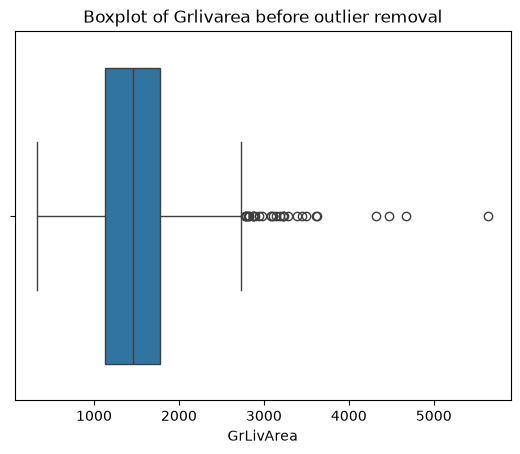

In [9]:
sns.boxplot(x = home['GrLivArea'])
plt.title('Boxplot of Grlivarea before outlier removal')

The boxplot above shows that there are outliers present in the GrLivArea column

Capping works by setting a maximum and/or minimum limit on values in a 
numerical column. Any value above the maximum limit is replaced with the 
maximum, and any value below the minimum limit is replaced with the minimum.

In [10]:
def cap_outliers_iqr(df, columns, factor=1.5):
    df_capped = df.copy()
    
    for col in columns:
        Q1 = df_capped[col].quantile(0.25)
        Q3 = df_capped[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - factor * IQR
        upper_bound = Q3 + factor * IQR
        
        # Calculate how many values fall outside boundaries before capping
        lower_outliers = (df_capped[col] < lower_bound).sum()
        upper_outliers = (df_capped[col] > upper_bound).sum()
        
        # Clip feature values to calculated IQR boundaries
        df_capped[col] = df_capped[col].clip(lower=lower_bound, upper=upper_bound)
        
        print(f"{col:12s} | Lower capped: {lower_outliers:3d} | Upper capped: {upper_outliers:3d} | Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
        
    return df_capped

features_to_cap = ['GrLivArea', 'LotArea', 'TotalBsmtSF']

home = cap_outliers_iqr(home, features_to_cap)

GrLivArea    | Lower capped:   0 | Upper capped:  31 | Bounds: [158.62, 2747.62]
LotArea      | Lower capped:   2 | Upper capped:  67 | Bounds: [1481.50, 17673.50]
TotalBsmtSF  | Lower capped:  37 | Upper capped:  24 | Bounds: [42.00, 2052.00]


Text(0.5, 1.0, 'Boxplot of Grlivarea before outlier removal')

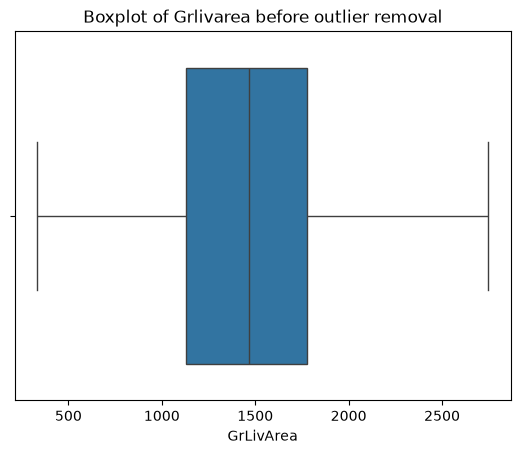

In [11]:
sns.boxplot(x = home['GrLivArea'])
plt.title('Boxplot of Grlivarea before outlier removal')

The box plot above shows that the GRLivArea column is more clean due to removal of outliers

## 4. Feature Engineering

New features that capture combined/derived information the raw columns don't
express on their own.

In [12]:
home['house_age'] = home['YrSold'] - home['YearBuilt']
home['total_sqft'] = home['TotalBsmtSF'] + home['1stFlrSF'] + home['2ndFlrSF']
home['area_per_room'] = home['GrLivArea'] / (home['TotRmsAbvGrd'] + 1)
home['garage_area_ratio'] = home['GarageArea'] / (home['GrLivArea'] + 1)
home['overall_space'] = home['GrLivArea'] + home['GarageArea']

Feature engineering was performed inorder for the model to find new patterns when learning

## 5. Target Transformation

Log transform was performed on Sale price inorder for the values to be distributed evenly so that the model wont focus or treat some with more importance than the other 

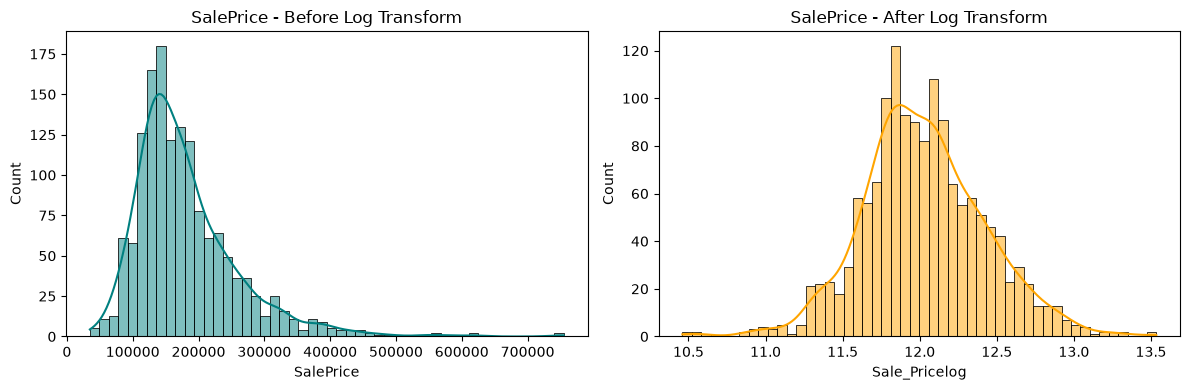

In [13]:
home['Sale_Pricelog'] = np.log1p(home['SalePrice'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(home['SalePrice'], bins=50, color='teal', edgecolor='black',ax = axes[0], kde = True)
axes[0].set_title('SalePrice - Before Log Transform')
sns.histplot(home['Sale_Pricelog'], bins=50, color='orange', edgecolor='black',kde = True, ax = axes[1])
axes[1].set_title('SalePrice - After Log Transform')
plt.tight_layout()
plt.show()

The subplots above shows the before and after log transform of saleprice. The Sale price before the log transform was right skewed and the Sale price after the log transform is more evenly distributed.

## 6. Exploratory Data Analysis

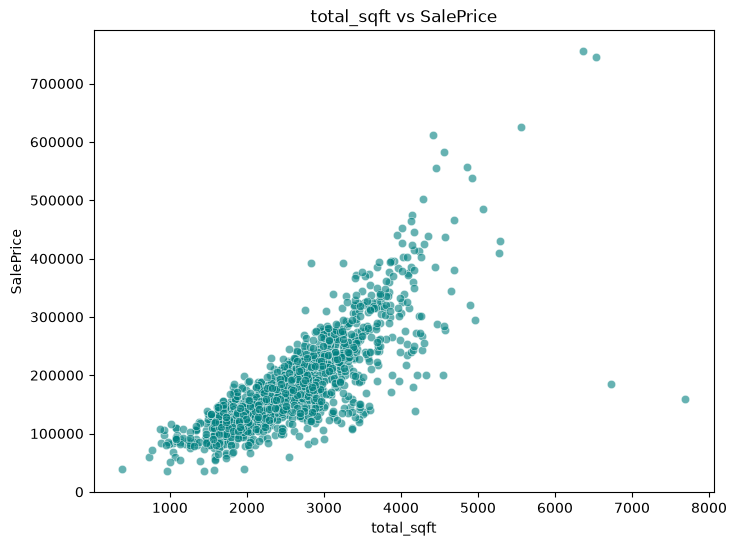

In [14]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='total_sqft', y='SalePrice', data=home, alpha=0.6, color='teal')
plt.title('total_sqft vs SalePrice')
plt.show()

The scatter plot above shows that if  the total size(in square feet) of the home increases the price would also increase. This shows a positive correlation with SalePrice

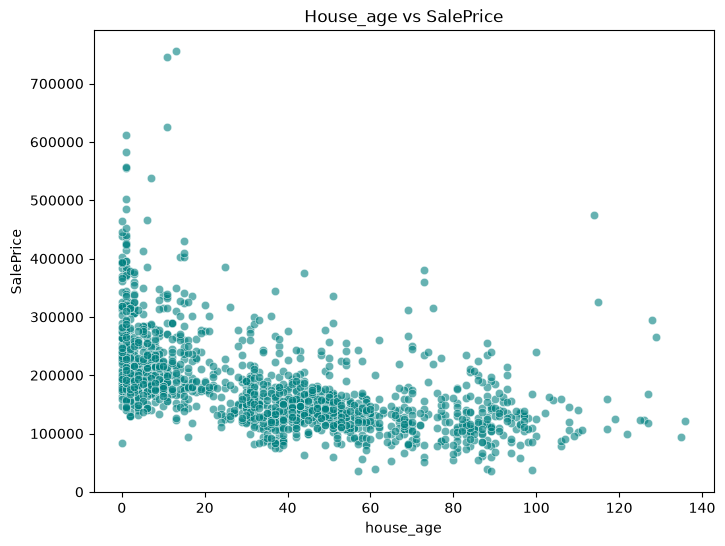

In [15]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='house_age', y='SalePrice', data=home, alpha=0.6, color='teal')
plt.title('House_age vs SalePrice')
plt.show()

The scatter plot above shows that if the age of the house increases the price of the homw would also reduce. This shows a negative corellation with Sale price

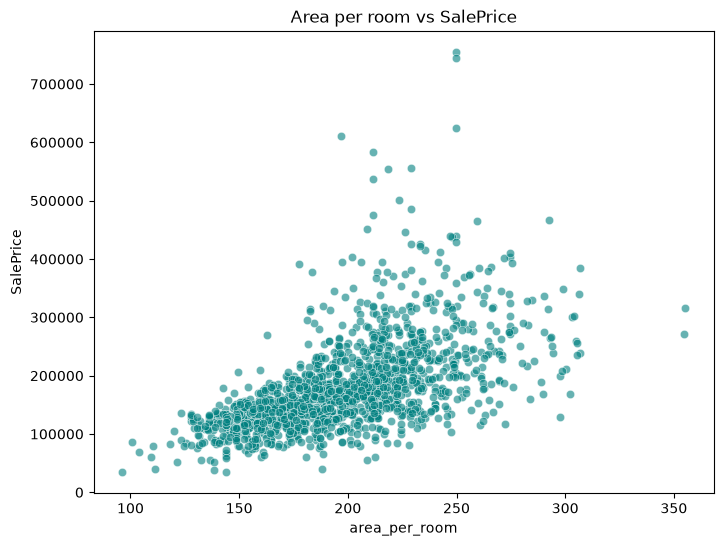

In [16]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='area_per_room', y='SalePrice', data=home, alpha=0.6, color='teal')
plt.title('Area per room vs SalePrice')
plt.show()

The scatter plot above shows that as area per room increases, the sale price also increases. This shows a positive corellation with SalePrice

Text(0.5, 1.0, 'Neighbourhoods with the highest average saleprice')

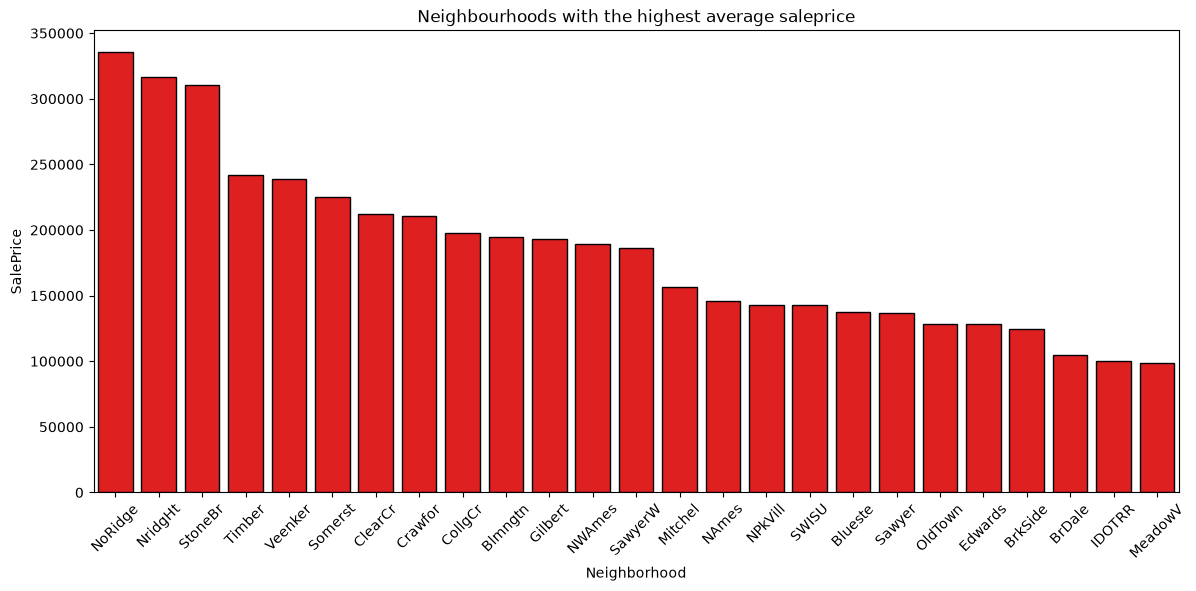

In [17]:
plt.figure(figsize = (14,6))
home_neighborhood = home.groupby('Neighborhood')[['SalePrice']].mean()
home_neighborhood = home_neighborhood.sort_values(by=['SalePrice'], ascending= False)
sns.barplot(x = 'Neighborhood', y = 'SalePrice', data = home_neighborhood , color = 'red', edgecolor = 'black')
plt.xticks(rotation = 45)
plt.title('Neighbourhoods with the highest average saleprice')


The barplot above shows the neighbourhoods with the highest average sale price. Norrige had the highest average with an average price of homes exceeding 250000 dollars

Text(0.5, 1.0, 'Boxplot for relationship of overall quality with saleprice')

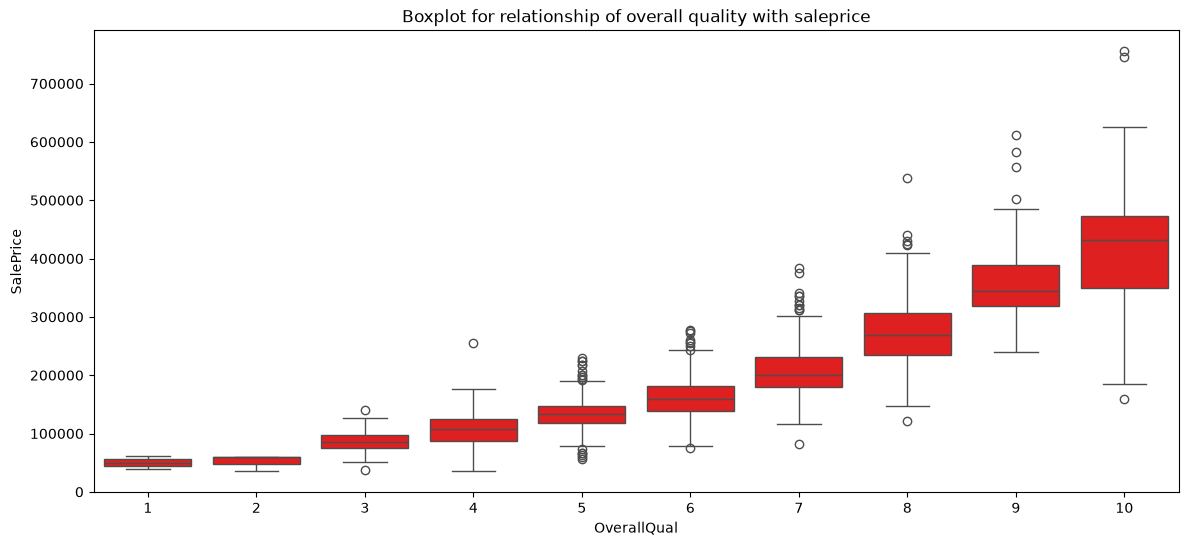

In [18]:
plt.figure(figsize = (14,6))
sns.boxplot(x = 'OverallQual', y = 'SalePrice', data = home , color = 'red')
plt.title('Boxplot for relationship of overall quality with saleprice')


The boxplot above shows that as the overall quality of the home increases, the price of homes increases.

In [19]:
numeric_cols = home.select_dtypes(include=['number']).columns.tolist()

In [20]:
cols_to_drop = [
    'YrSold', 
    'YearBuilt', 
    'TotalBsmtSF', 
    '1stFlrSF', 
    '2ndFlrSF', 
    'GrLivArea', 
    'TotRmsAbvGrd', 
    'GarageArea',
    'Sale_Pricelog',
    'overall_space'
]
corr_cols = [col for col in numeric_cols if col not in cols_to_drop]

Columns which could lead to multicollinearity were removed inorder for the heat map to look more clean

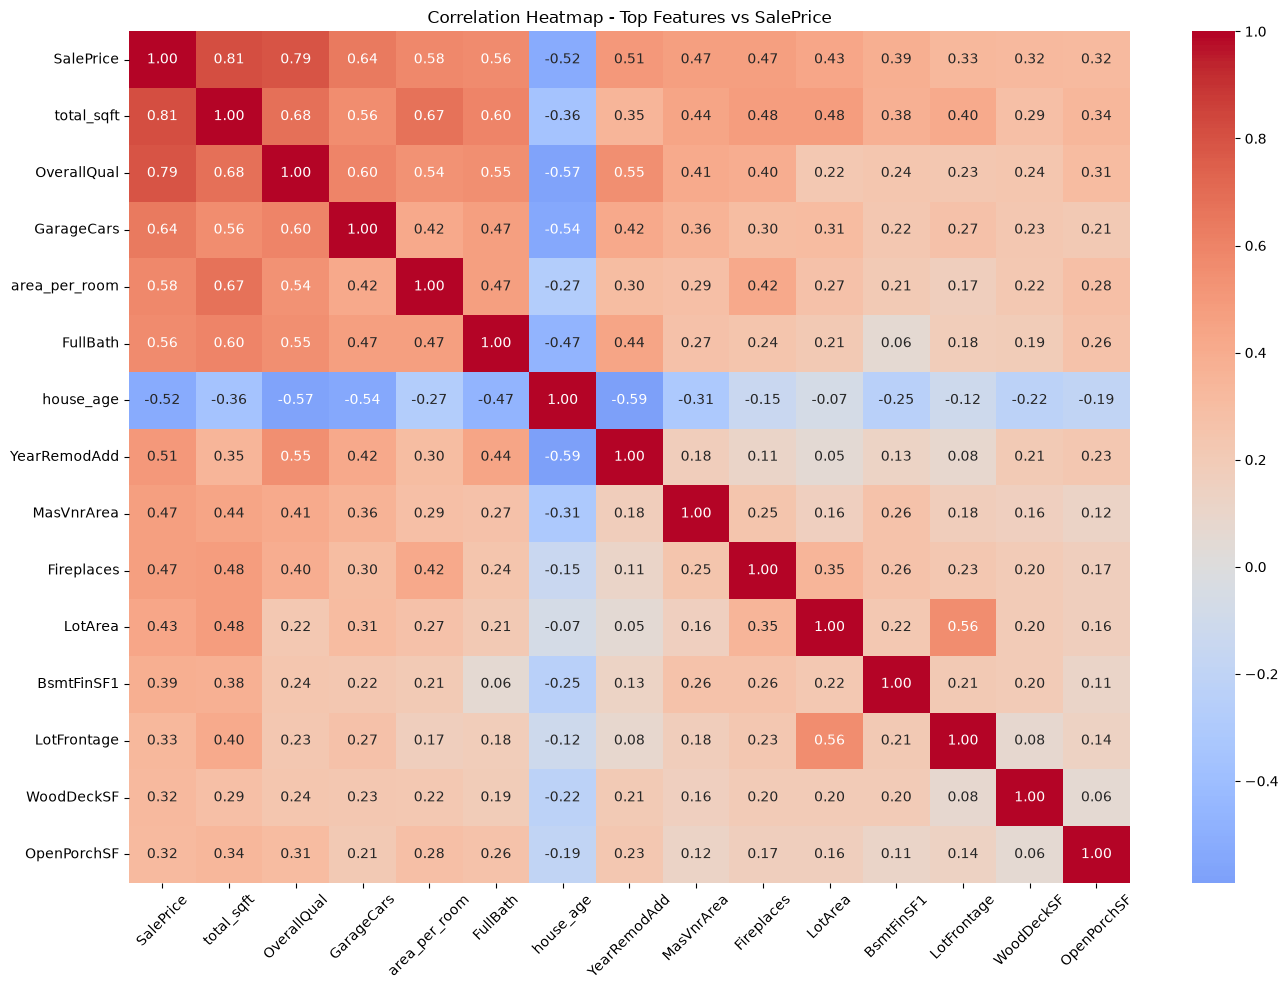

In [21]:
plt.figure(figsize=(14, 10))
corr = home[corr_cols].corr()
top_corr = corr['SalePrice'].abs().sort_values(ascending=False).head(15).index
sns.heatmap(home[top_corr].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - Top Features vs SalePrice')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The corellation heat map above show the corellation of features with sale price and the corellation of features with each other. Features like overallqual(overall quality of home ), total_sqft(total size of the home )and Garage cars show strong positive corellation with Saleprice meaning the more they increase, the more the Saleprice increase.While House age was the only feature that showed a strong negative corellation with sale price meaning that the more hose age increases, the less the sale price decreases



## 7. Encoding

Models can't understand string data, so categorical columns are converted into numbers via one-hot encoding.Also, columns which could lead to multicolinearity were removed to reduce noise.

In [22]:
cat_cols = home.select_dtypes(include = 'object').columns
train_encoded = pd.get_dummies(home,columns= cat_cols,drop_first= True)
x = train_encoded.drop(columns = ['SalePrice'
                                  ,'Sale_Pricelog'
                                  ,'YrSold', 
    'YearBuilt', 
    'TotalBsmtSF', 
    '1stFlrSF', 
    '2ndFlrSF', 
    'GrLivArea', 
    'TotRmsAbvGrd', 
    'GarageArea',
    'overall_space'])
y = home['Sale_Pricelog']

C:\Users\alegb\AppData\Local\Temp\ipykernel_18204\936170317.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = home.select_dtypes(include = 'object').columns


## 8. Train-Test split

The data was then splitted into 80% for training and 20% for testing 

In [23]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 23)

## 9. Scaling

Scaling involves transforming your feature values into a consistent range, so that no single feature dominates the model because of its magnitude.Scaling was fitted on only the training data so that the data wont be leaked to the model.

In [24]:
scaler = MinMaxScaler()
x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train), columns=x_train.columns)
x_test_scaled  = pd.DataFrame(scaler.transform(x_test), columns=x_test.columns)

## 8. Recursive Feature Elimination  (RFE)

Rfe is a feature selection method which works by training a model on all your features, ranking each feature by importance, removing the weakest feature, retraining on the remaining features and repeating until it reaches the number of features specified.Ridge was used because iy shrinks all coefficients smoothly without zeroing them arbitrarily, which makes it a stable, well-behaved ranker under multicollinearity

In [25]:
rfe_model = Ridge(alpha=1.0)
rfe = RFE(rfe_model, n_features_to_select=20)
rfe.fit(x_train_scaled, y_train)

selected_features = x_train_scaled.columns[rfe.support_]
print(f"Selected {len(selected_features)} features:", list(selected_features))

x_train_rfe = x_train_scaled[selected_features]
x_test_rfe = x_test_scaled[selected_features]

Selected 20 features: ['LotArea', 'OverallQual', 'OverallCond', 'BsmtFullBath', 'GarageCars', 'house_age', 'total_sqft', 'area_per_room', 'garage_area_ratio', 'MSZoning_FV', 'MSZoning_RH', 'MSZoning_RL', 'MSZoning_RM', 'Neighborhood_StoneBr', 'Condition1_RRAe', 'Condition2_PosN', 'Heating_Grav', 'Functional_Maj2', 'Functional_Sev', 'PoolQC_Gd']


In [26]:
selected_features

Index(['LotArea', 'OverallQual', 'OverallCond', 'BsmtFullBath', 'GarageCars',
       'house_age', 'total_sqft', 'area_per_room', 'garage_area_ratio',
       'MSZoning_FV', 'MSZoning_RH', 'MSZoning_RL', 'MSZoning_RM',
       'Neighborhood_StoneBr', 'Condition1_RRAe', 'Condition2_PosN',
       'Heating_Grav', 'Functional_Maj2', 'Functional_Sev', 'PoolQC_Gd'],
      dtype='str')

20 features were selected via RFE. Testing showed R2=0.9106 at 20 features versus
R2=0.9125 at 60 features — a gain of only 0.019 for 3x the features. Since this
model is intended for API use, where every additional feature is one more input
the caller has to supply correctly, the small performance gain wasn't worth the
added complexity, so 20 was kept.

## 9.  Baseline Model Comparison

In [27]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1),
    'Lasso': Lasso(alpha=0.001),
    'Random Forest': RandomForestRegressor(random_state=23),
    'XGBoost': XGBRegressor(random_state=23)
}

y_test_actual = np.expm1(y_test)
results = []

for name, model in models.items():
    model.fit(x_train_rfe, y_train)
    log_preds = model.predict(x_test_rfe)
    actual_preds = np.expm1(log_preds)

    r2 = r2_score(y_test_actual, actual_preds)
    mse = mean_squared_error(y_test_actual, actual_preds)
    rmse = np.sqrt(mse)

    results.append({'Model': name, 'R2': round(r2, 4), 'MSE': round(mse, 2), 'RMSE': round(rmse, 2)})

results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
display(results_df)

,Model,R2,MSE,RMSE
0,Linear Regression,0.9077,4.654696e+08,21574.74
1,Ridge,0.9038,4.852404e+08,22028.17
2,Lasso,0.9004,5.019661e+08,22404.60
4,XGBoost,0.8969,5.196040e+08,22794.82
3,Random Forest,0.8790,6.099990e+08,24698.16


After evaluating the base model on the test set the best performing model was XGboost with a R2 of 0.9077 and rmse of $21574.74. This means that that the model explains 90.77 percent of why house prices vary from the average.The models predictions on an average are also off by $21574.74

## 10. Hyperparameter Tuning

Only the top performers get tuned. Lasso  the best linear model uses
GridSearchCV since its search space is small .the best tree-based model(XGboost) uses
RandomizedSearchCV since its search space is much larger.

In [28]:
lasso_params = {'alpha': np.logspace(-4, 2, 40)}
lasso_grid = GridSearchCV(Lasso(max_iter=20000), lasso_params, cv=5, scoring='r2', n_jobs=-1)
lasso_grid.fit(x_train_rfe, y_train)

print("Best lasso alpha:", lasso_grid.best_params_)
print("Best lasso CV R2:", round(lasso_grid.best_score_, 4))

Best lasso alpha: {'alpha': np.float64(0.0008376776400682924)}
Best lasso CV R2: 0.8586


In [29]:
xgb_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10],               # Replaces [10..30, None] to prevent heavy overfitting
    'learning_rate': [0.01, 0.05, 0.1, 0.2],  # Crucial boosting step size
    'min_child_weight': [1, 3, 5, 10],        # Analog to min_samples_leaf / min_samples_split
    'subsample': [0.6, 0.8, 1.0],             # Row sampling ratio
    'colsample_bytree': [0.6, 0.8, 1.0],      # Feature sampling ratio
    'gamma': [0, 0.1, 0.2]
}
xgb_random = RandomizedSearchCV(
XGBRegressor(random_state=23), xgb_params, n_iter=50, cv=5,
scoring='r2', random_state=23, n_jobs=-1)

xgb_random.fit(x_train_rfe, y_train)

print("Best xgb params:", xgb_random.best_params_)
print("Best xgb CV R2:", round(xgb_random.best_score_, 4))

Best xgb params: {'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.6}
Best xgb CV R2: 0.8787


In [30]:
print("Tuned XGBoost params:", xgb_random.best_params_)

Tuned XGBoost params: {'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.6}


## 11. Evaluate Tuned Models on the Test Set

The tuned models were now evaluated again on the test set

In [31]:
tuned_models = {
    'lasso (tuned)': lasso_grid.best_estimator_,
    'Xgboost (tuned)': xgb_random.best_estimator_
}

for name, model in tuned_models.items():
    log_preds = model.predict(x_test_rfe)
    actual_preds = np.expm1(log_preds)
    r2 = r2_score(y_test_actual, actual_preds)
    rmse = np.sqrt(mean_squared_error(y_test_actual, actual_preds))
    print(f"{name}: R2={r2:.4f}, RMSE=${rmse:,.2f}")

lasso (tuned): R2=0.9019, RMSE=$22,238.79
Xgboost (tuned): R2=0.9044, RMSE=$21,950.01


After evaluating the tuned models on the test set xgboost metrics were lower than that of the base model with a R2 of 0.9044 and rmse of $21950. The final model that would be selected is the base xgboost which had the highest performance.

## 12. Diagnostics — Actual vs Predicted, Residuals, Feature Importance

Using the base xgboost model as the final model 

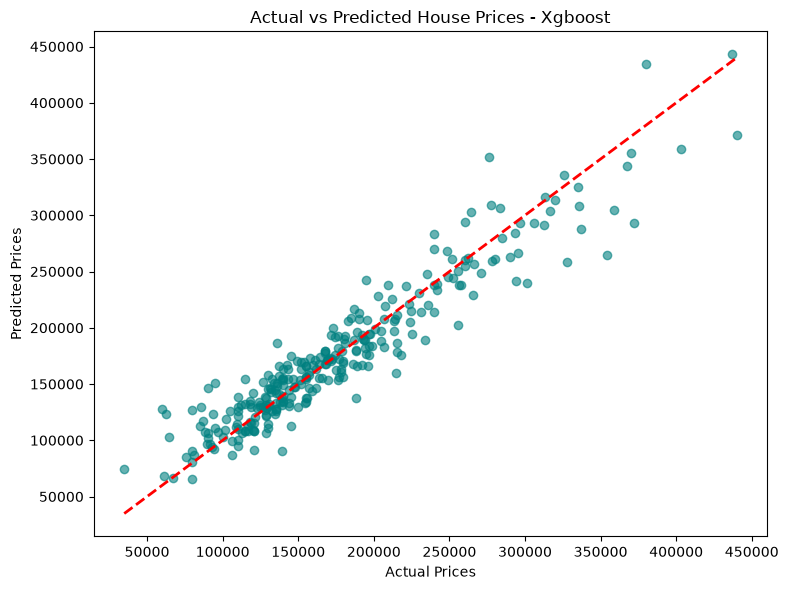

In [32]:
final_model = models['XGBoost']
log_preds = final_model.predict(x_test_rfe)
actual_preds = np.expm1(log_preds)
actual_y = np.expm1(y_test)

plt.figure(figsize=(8, 6))
plt.scatter(actual_y, actual_preds, alpha=0.6, color='teal')
plt.plot([actual_y.min(), actual_y.max()], [actual_y.min(), actual_y.max()], 'r--', linewidth=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted House Prices - Xgboost')
plt.tight_layout()
plt.show()

The scatterplot above shows actual vs predicted values. The red dashed line 
represents the line of perfect prediction — where the actual value would 
exactly equal the predicted value. The closer the dots cluster to this line, 
the more accurate the model's predictions are. The model predicts well across the bulk of the price range but shows a 
consistent tendency to underpredict for houses above approximately $450,000. 
This is expected — high-value homes are underrepresented in the training 
data, giving the model less signal to learn their pricing patterns from.

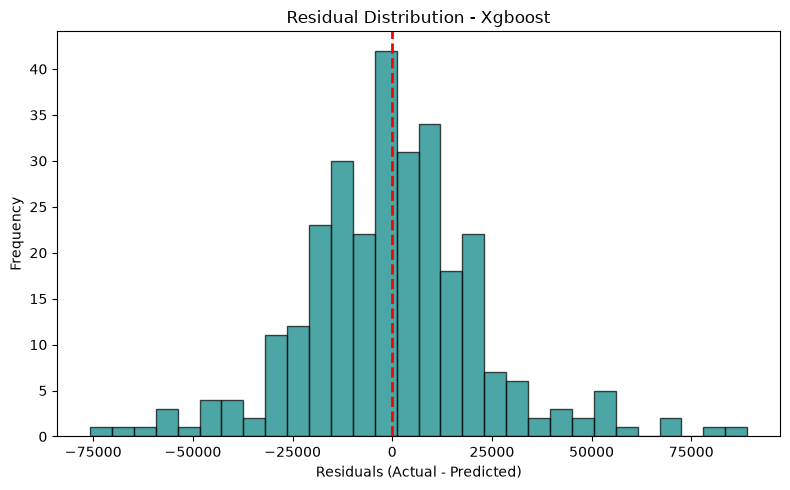

Mean residual: $100.15
Std of residuals: $22,833.74


In [33]:
residuals = actual_y - actual_preds

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30, color='teal', edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Residual Distribution - Xgboost')
plt.tight_layout()
plt.show()

print(f"Mean residual: ${residuals.mean():,.2f}")
print(f"Std of residuals: ${residuals.std():,.2f}")

The near-zero mean residual confirms that the model predictions are well-calibrated with virtually no systematic global bias. On average across the test set, predicted prices underestimate actual market values by only ~$100.15 indicating a balanced error distribution centered near zero

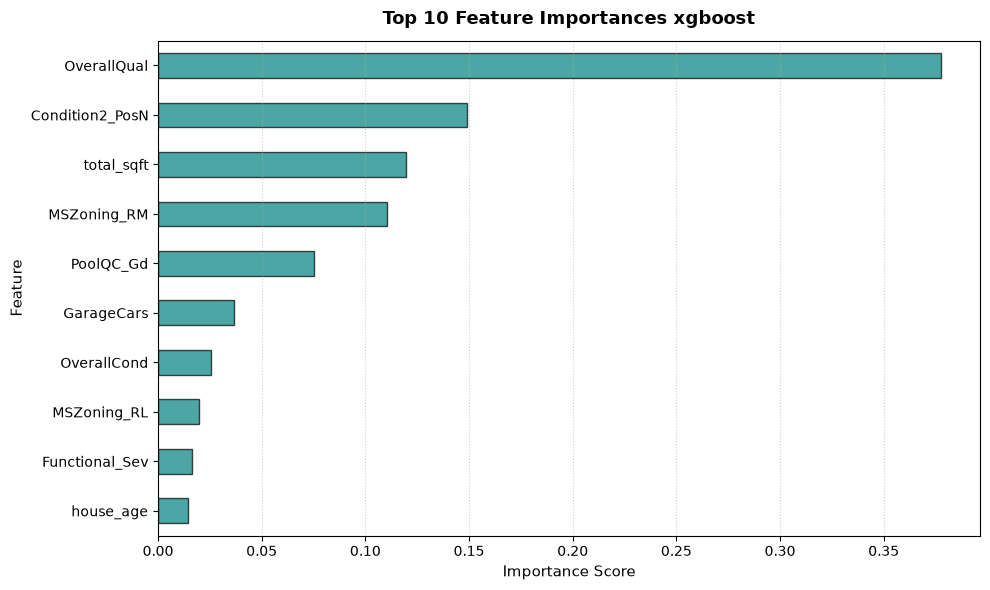

In [34]:
import matplotlib.pyplot as plt
import pandas as pd

importances = pd.Series(final_model.feature_importances_, index=x_train_rfe.columns)
top_features = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_features.sort_values(ascending=True).plot(
    kind='barh', 
    color='teal', 
    edgecolor='black', 
    alpha=0.7
)
plt.xlabel('Importance Score', fontsize=11)
plt.ylabel('Feature', fontsize=11)
plt.title('Top 10 Feature Importances xgboost', fontsize=13, fontweight='bold', pad=12)
plt.grid(True, linestyle=':', alpha=0.6, axis='x')

plt.tight_layout()
plt.show()

The bar plot above shows the features with the most importance to the model's
predictions. The most important feature was `OverallQual` (overall quality of the home), which influences the model's prediction more than any
other feature.

## 13. Save the Model pipeline

In [35]:
regressor_step = models['XGBoost'] 

full_pipeline = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('feature_selection', RFE(Ridge(alpha=1.0, random_state= 23), n_features_to_select=15)),
    ('regressor', regressor_step)
])

full_pipeline.fit(x_train, y_train)
joblib.dump(full_pipeline, 'house_price_pipeline.pkl')

print("Pipeline saved successfully.")

Pipeline saved successfully.


I used a scikit-learn Pipeline to chain together scaling, RFE-based feature selection, and the final model into one object.

## 14. Conclusion

This project built an end-to-end machine learning pipeline to predict house
prices. After data cleaning, feature engineering, and exploratory analysis,
five models were compared, and the top performers were tuned with
GridSearchCV / RandomizedSearchCV.

Key findings:
- Overall quality was the strongest driver of price.
- House age negatively affects price — older houses are worth less.
- Engineered features (`total_sqft`, `house_age`) ranked among the most
  important predictors, confirming the feature engineering added real value.
- Log-transforming the target improved model behavior and produced residuals
  centered near zero with no major systematic bias.
- Hyperparameter tuning was tested on the top linear and tree-based models,
  but did not improve on XGBoost's untuned baseline performance
  (R²=0.9077 vs R²=0.9044 tuned) — the baseline XGBoost model was therefore
  selected as final.

The final baseline XGBoost model and its supporting pipeline (scaler, 
RFE feature selection) were saved as a single object for use in a 
deployed prediction API.